In [1]:
import sys
# For notebooks inside research/ftir_hips_chem/:
sys.path.insert(0, './scripts')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.cross_decomposition import PLSRegression

# Config + data
from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
)

# Exclusions (the IMPROVE RDS cohort already carries its model exclusions; no new
# sample is silently removed here—eligibility and missing-reference rows are audited.)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

# Data loading / matching
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors

# Plotting—importing applies the repository white-background default.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

from pls_transfer import (
    FTIRTransferPaths, load_current_pls_model, vip_scores,
    select_components_cv, nested_cv_predictions, regression_metrics,
    score_metric, project_scores, mahalanobis_distance_squared,
    pairwise_score_distance_squared, spectral_q_residual, offset_correct,
    vip_overlap_summary, summarize_vip_bands, spaced_peak_table,
)

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True)
PATHS = FTIRTransferPaths.defaults()
TABLE_DIR = Path('output/tables/pls_transfer')
PLOT_DIR = Path('output/plots/pls_transfer')
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Does the current IMPROVE EC calibration lean on OC-related spectral features?

## tl;dr

The current IMPROVE EC calibration shares substantial predictor structure with the current OC
calibration: VIP-profile Spearman r = **0.934**, **179 of the top 200** wavenumbers overlap, and
**58.5% of EC squared-VIP mass** lies at wavenumbers where OC VIP ≥ 1. This supports the concern
that EC prediction leans heavily on OC-associated spectral covariance, while not proving that any
individual band is uniquely causal. The Python reconstructions reproduce the exported R fitted
values to maximum absolute differences of **5.1×10⁻⁵ (EC)** and **0.0032 (OC)**.

## Context & Methods

This notebook reconstructs the current July 7 EC and OC PLS models from their exported
RDS components, verifies the Python reconstruction against the R fitted values, and
computes VIP using Eq. (14) in Takahama et al. (2019). “OC-related” is defined operationally:
a wavenumber is OC-important when the current OC model has VIP ≥ 1 there. This avoids
claiming a unique chemical assignment where overlapping FTIR bands make one uncertain.

### Key Assumptions

- The checked-in NPZ/CSV exports are lossless representations of the named RDS files.
- VIP is interpreted post hoc; it does not prove that a band is uniquely causal.
- The EC and OC models use the same 2722-point wavenumber grid.

In [2]:
source_inventory = PATHS.validate()
display(source_inventory)
if not source_inventory['exists'].all():
    raise FileNotFoundError(source_inventory.loc[~source_inventory['exists'], 'path'].tolist())

ec = load_current_pls_model(PATHS.ftir_dir, 'EC')
oc = load_current_pls_model(PATHS.ftir_dir, 'OC')
assert np.allclose(ec.wavenumbers, oc.wavenumbers)

reconstruction = pd.DataFrame([
    {'model': 'EC', 'n': len(ec.y), 'components': ec.chosen_n_components,
     'max_abs_difference_vs_R': ec.r_prediction_max_abs_error,
     'median_abs_difference_vs_R': ec.r_prediction_median_abs_error},
    {'model': 'OC', 'n': len(oc.y), 'components': oc.chosen_n_components,
     'max_abs_difference_vs_R': oc.r_prediction_max_abs_error,
     'median_abs_difference_vs_R': oc.r_prediction_median_abs_error},
])
reconstruction.to_csv(TABLE_DIR / 'current_model_reconstruction_check.csv', index=False)
display(reconstruction)

,source,path,exists,size_mb
0,ftir_dir,/Users/ahmadjalil/Library/CloudStorage/GoogleD...,True,0.000576
1,etad_dir,/Users/ahmadjalil/Library/CloudStorage/GoogleD...,True,0.000480
2,spartan_hips_primary,/Users/ahmadjalil/Library/CloudStorage/GoogleD...,True,0.961811
3,spartan_hips_backup,/Users/ahmadjalil/Library/CloudStorage/GoogleD...,True,0.747680


,model,n,components,max_abs_difference_vs_R,median_abs_difference_vs_R
0,EC,906,31,0.000051,0.000009
1,OC,935,53,0.003197,0.000531


## Results

### 1. VIP overlap directly tests whether EC relies on the same predictors as OC

In [3]:
ec_vip = vip_scores(ec.model)
oc_vip = vip_scores(oc.model)
overlap = vip_overlap_summary(ec_vip, oc_vip, threshold=1.0, top_n=200)
overlap_table = pd.DataFrame([overlap])
overlap_table.to_csv(TABLE_DIR / 'ec_oc_vip_overlap.csv', index=False)

vip_profile = pd.DataFrame({
    'wavenumber_cm-1': ec.wavenumbers,
    'EC_VIP': ec_vip,
    'OC_VIP': oc_vip,
    'EC_important': ec_vip >= 1.0,
    'OC_important': oc_vip >= 1.0,
})
vip_profile.to_csv(TABLE_DIR / 'current_ec_oc_vip_profiles.csv', index=False)
display(overlap_table)

,spearman_r,important_a_n,important_b_n,important_jaccard,top_n,top_n_overlap,top_n_overlap_fraction,a_vip_mass_on_b_important
0,0.934386,896,937,0.764196,200,179,0.895,0.585193


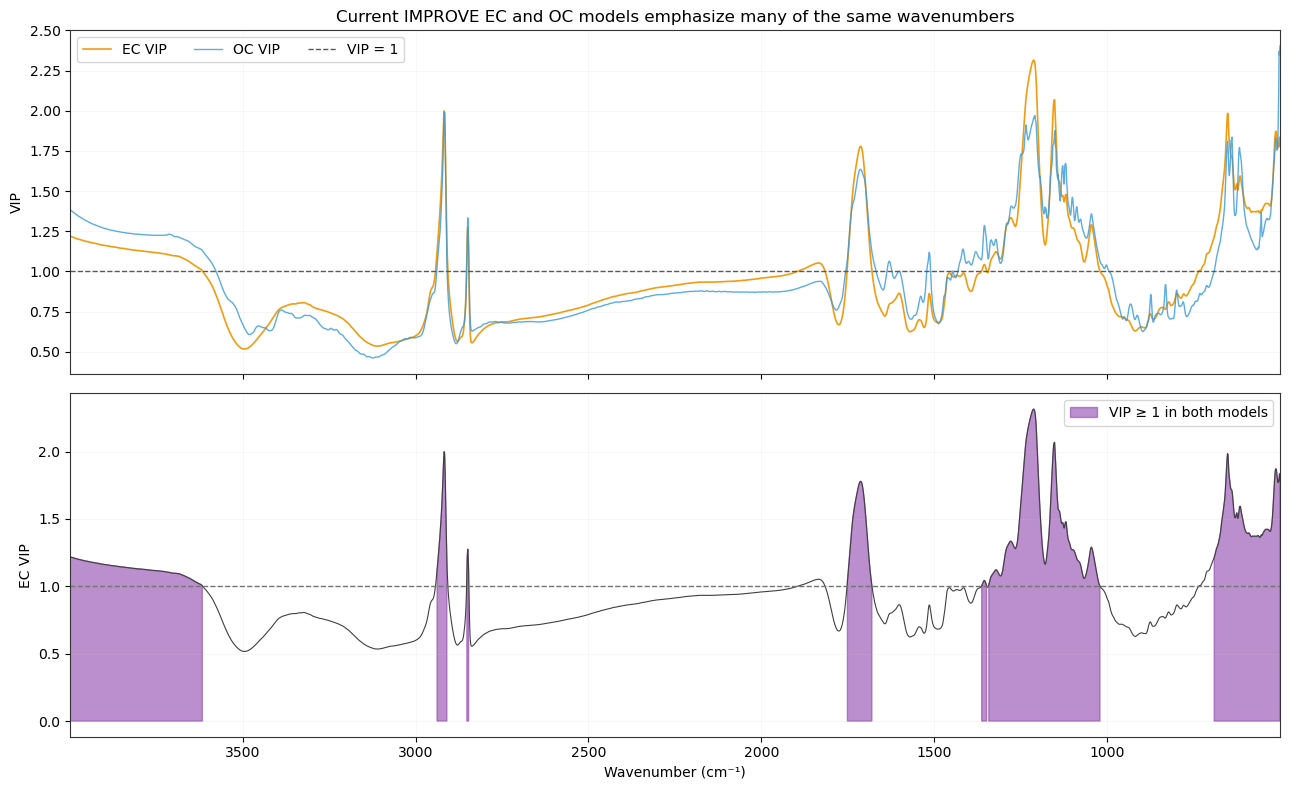

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(ec.wavenumbers, ec_vip, color=SITES['Addis_Ababa']['color'], lw=1.2, label='EC VIP')
axes[0].plot(ec.wavenumbers, oc_vip, color='#3498DB', lw=1.0, alpha=0.8, label='OC VIP')
axes[0].axhline(1.0, color='0.35', ls='--', lw=1, label='VIP = 1')
axes[0].set_ylabel('VIP')
axes[0].set_title('Current IMPROVE EC and OC models emphasize many of the same wavenumbers')
axes[0].legend(ncol=3)

shared = (ec_vip >= 1.0) & (oc_vip >= 1.0)
axes[1].fill_between(ec.wavenumbers, 0, ec_vip, where=shared,
                     color='#8E44AD', alpha=0.6, label='VIP ≥ 1 in both models')
axes[1].plot(ec.wavenumbers, ec_vip, color='0.25', lw=0.8)
axes[1].axhline(1.0, color='0.45', ls='--', lw=1)
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('EC VIP')
axes[1].legend()
for ax in axes:
    ax.set_xlim(ec.wavenumbers.max(), ec.wavenumbers.min())
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'current_ec_oc_vip_overlap.png', dpi=180, bbox_inches='tight')
plt.show()

### 2. Broad-band summaries are safer than assigning individual overlapping peaks

In [5]:
ec_bands = summarize_vip_bands(ec.wavenumbers, ec_vip).assign(model='EC')
oc_bands = summarize_vip_bands(oc.wavenumbers, oc_vip).assign(model='OC')
band_summary = pd.concat([ec_bands, oc_bands], ignore_index=True)
band_summary.to_csv(TABLE_DIR / 'current_model_vip_band_summary.csv', index=False)

peak_score = ec_vip * oc_vip
shared_peaks = spaced_peak_table(ec.wavenumbers, peak_score, n_peaks=20)
shared_peaks['EC_VIP'] = ec_vip[shared_peaks['index']]
shared_peaks['OC_VIP'] = oc_vip[shared_peaks['index']]
shared_peaks.to_csv(TABLE_DIR / 'ec_oc_shared_vip_peaks.csv', index=False)
display(band_summary.pivot(index='band', columns='model', values='vip2_mass_fraction'))
display(shared_peaks.head(12))

model,EC,OC
band,,
O-H / N-H region,0.078515,0.077314
aliphatic C-H stretch,0.046662,0.043605
amide / aromatic / N-H region,0.023542,0.034304
carbonyl region,0.074081,0.072184
fingerprint region,0.430658,0.418792


,index,wavenumber_cm-1,score,EC_VIP,OC_VIP
0,2169,1209.812256,4.538305,2.304183,1.969594
1,2720,501.409973,4.304550,1.834898,2.345935
2,2150,1234.239990,3.989052,2.087668,1.910769
3,841,2917.177490,3.971812,1.998610,1.987287
4,2214,1151.957275,3.859640,2.068282,1.866109
5,2603,651.833008,3.590910,1.984160,1.809788
6,1778,1712.507935,2.909258,1.779007,1.635327
7,2630,617.119995,2.814664,1.589364,1.770938
8,2239,1119.815674,2.473730,1.479192,1.672352
9,2134,1254.810669,2.384552,1.450486,1.643968


## Takeaways

- EC and OC feature rankings are strongly coupled, so an EC transfer failure can plausibly follow
  a change in OC/EC or functional-group covariance even if EC itself is present.
- The EC model places **43.1%** of squared-VIP mass below 1500 cm⁻¹, **7.4%** in the broad carbonyl
  region, and **4.7%** in the aliphatic C–H stretch. Cutting the spectrum at 1500 cm⁻¹ would discard
  a large share of the model's current information.
- VIP is a post hoc importance diagnostic. These overlaps motivate targeted transfer tests; they
  do not assign a unique molecule or establish causation.